# Train and Save

Trains a single model (`model_type` = `"spike"` or `"vanilla"`) on the causal Associative
Recall task and saves everything to `runs/{model_type}_{num_kv_pairs}_{num_keys}_{num_values}/`
(e.g. `runs/spike_3_32_32/`):

- `checkpoint_step{N}.pt` -- a state_dict every `checkpoint_every` steps (plus whichever step
  training actually stops on, even if `early_stop_acc` fires between checkpoints).
- `eval_curve.png` -- the eval loss/accuracy curves.
- `history.json` -- the raw step/loss/acc arrays behind that plot.

In [31]:
import json
import os

import torch

from data import generate_batch, key_position_mask, seq_len, vocab_size
from models import SpikingTransformer, VanillaTransformer
from train import compute_loss_and_acc, pick_device, plot_history, train_one_model


## Config

In [32]:
model_type = "spike"  # "spike" or "vanilla"

num_kv_pairs = 16
num_rounds = 2
num_keys = 32
num_values = 32

dim = 128
depth = 2
num_heads = 4
T = 10  # spiking simulation time steps (ignored for model_type == "vanilla")

batch_size = 64
eval_batch_size = 512
steps = 15000
eval_every = 20
checkpoint_every = 100
early_stop_acc = 0.99
lr = 3e-3
seed = 0

torch.manual_seed(seed)
device = pick_device()

V = vocab_size(num_keys, num_values)
L = seq_len(num_kv_pairs, num_rounds)
mask = key_position_mask(num_kv_pairs, num_rounds, device=device)

run_name = f"{model_type}_{num_kv_pairs}_{num_keys}_{num_values}"
run_dir = os.path.join("runs", run_name)
os.makedirs(run_dir, exist_ok=True)
print(f"device={device}, vocab_size={V}, seq_len={L}, run_dir={run_dir}")


device=mps, vocab_size=64, seq_len=64, run_dir=runs/spike_16_32_32


## Model

In [33]:
if model_type == "spike":
    model = SpikingTransformer(V, dim=dim, depth=depth, num_heads=num_heads, T=T, max_len=L).to(device)
elif model_type == "vanilla":
    model = VanillaTransformer(V, dim=dim, depth=depth, num_heads=num_heads, max_len=L).to(device)
else:
    raise ValueError(f"unknown model_type: {model_type!r}")

print(f"{model_type} params: {sum(p.numel() for p in model.parameters()):,}")


spike params: 424,256


## Training

Checkpoints every `checkpoint_every` steps (kept on CPU) and stops early at `early_stop_acc`.

In [ ]:
history = train_one_model(
    model_type, model, mask, device,
    num_kv_pairs=num_kv_pairs, num_rounds=num_rounds,
    num_keys=num_keys, num_values=num_values,
    batch_size=batch_size, eval_batch_size=eval_batch_size,
    steps=steps, eval_every=eval_every, lr=lr,
    checkpoint_every=checkpoint_every, early_stop_acc=early_stop_acc,
)


[spike] step    20 | eval loss 3.4869 | eval acc   4.1% | 13.3s
[spike] step    40 | eval loss 3.3899 | eval acc   6.6% | 25.0s
[spike] step    60 | eval loss 3.2434 | eval acc  10.2% | 37.0s
[spike] step    80 | eval loss 3.0585 | eval acc  13.7% | 48.9s
[spike] step   100 | eval loss 2.9383 | eval acc  14.7% | 60.5s
[spike] step   120 | eval loss 2.8789 | eval acc  14.8% | 72.3s
[spike] step   140 | eval loss 2.8417 | eval acc  14.7% | 84.0s
[spike] step   160 | eval loss 2.8226 | eval acc  14.4% | 95.7s
[spike] step   180 | eval loss 2.8075 | eval acc  14.5% | 107.4s
[spike] step   200 | eval loss 2.7777 | eval acc  14.6% | 119.1s
[spike] step   220 | eval loss 2.7544 | eval acc  14.5% | 130.8s
[spike] step   240 | eval loss 2.7404 | eval acc  14.3% | 143.0s
[spike] step   260 | eval loss 2.7171 | eval acc  14.7% | 154.7s
[spike] step   280 | eval loss 2.7174 | eval acc  14.1% | 166.8s
[spike] step   300 | eval loss 2.6971 | eval acc  14.1% | 178.8s
[spike] step   320 | eval loss 2.

## Save checkpoints

In [ ]:
ckpt_dir = os.path.join(run_dir, "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)

for step, state in history["checkpoints"]:
    torch.save(state, os.path.join(ckpt_dir, f"checkpoint_step{step:06d}.pt"))

# `history["checkpoints"]` always includes the final trained step (see train_one_model),
# whether training ran to completion or stopped early -- save that one again as best.pt
# at the run's top level (not inside checkpoints/), for convenience.
last_step, last_state = history["checkpoints"][-1]
torch.save(last_state, os.path.join(run_dir, "best.pt"))

print(f"saved {len(history['checkpoints'])} checkpoints to {ckpt_dir} (final step {last_step} also saved as {run_dir}/best.pt)")


saved 10 checkpoints to runs/spike_8_32_32/checkpoints (final step 940 also saved as runs/spike_8_32_32/best.pt)


## Save eval curve

saved eval curve to runs/spike_8_32_32/eval_curve.png
final eval acc: 99.1%


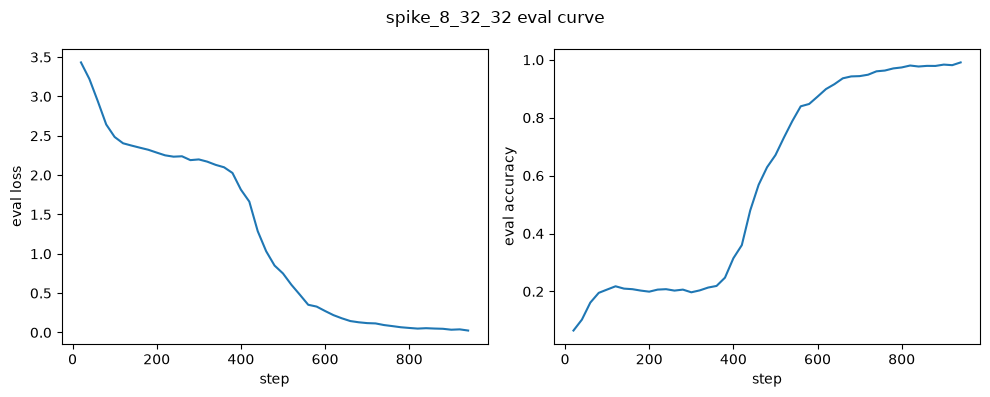

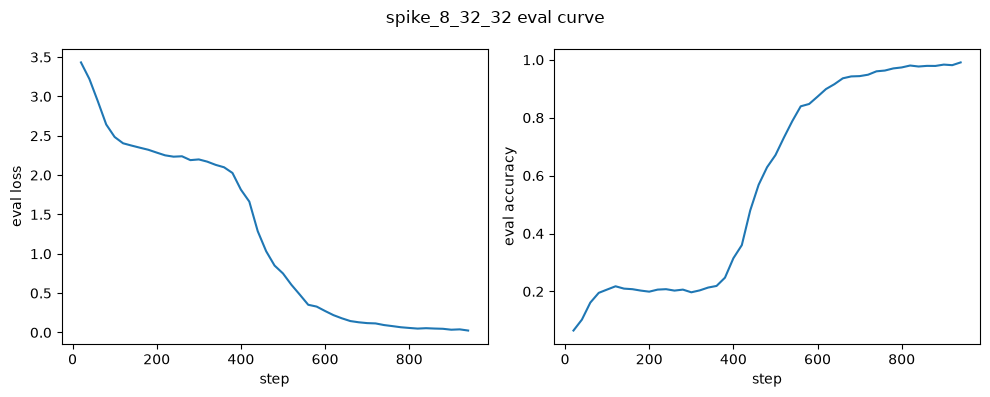

In [ ]:
curve_path = os.path.join(run_dir, "eval_curve.png")
fig = plot_history(history, f"{run_name} eval curve", save_path=curve_path)

with open(os.path.join(run_dir, "history.json"), "w") as f:
    json.dump({"step": history["step"], "loss": history["loss"], "acc": history["acc"]}, f, indent=2)

print(f"saved eval curve to {curve_path}")
print(f"final eval acc: {history['acc'][-1]*100:.1f}%")
fig
